In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os

# ■ tf.Tensor

# tf.Tensor (Tensorflow Tensor)
- **기본 Tensor 타입**으로, TensorFlow 연산에서 다루는 **실제 데이터**를 담고 있음.

- 연산 그래프에서 **계산 가능**한 값이며, Numpy처럼 연산이 가능한 다차원 배열.

- `tf.constant()`, `tf.Variable()`, 또는 어떤 '연산'의 결과로 만들어짐.

- https://www.tensorflow.org/api_docs/python/tf/Tensor

In [ ]:
# Numpy 의 array 처럼 Tensor 객체를 다룰수 있다

# Tensorflow 안에서 Array 를 많이 사용
#  ex) 이미지 데이터 --> Array 변환 --> Tensorflow 에 넣어주기


## tf.constant()
Creates a constant tensor from a tensor-like object

```python
tf.constant(
    value, dtype=None, shape=None, name='Const'
) -> Union[tf.Operation, ops._EagerTensorBase]
```

https://www.tensorflow.org/api_docs/python/tf/constant


In [2]:
# list -> tf.Tensor
tf.constant([1, 2, 3])

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

In [3]:
# tuple -> tf.Tensor
tf.constant(((1, 2, 3), (4, 5, 6)))

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 2, 3],
       [4, 5, 6]], dtype=int32)>

In [4]:
# Array -> tf.Tensor
tensor = tf.constant(np.arange(1, 5))
tensor

<tf.Tensor: shape=(4,), dtype=int64, numpy=array([1, 2, 3, 4])>

## Tensor 의 정보들

In [5]:
tensor.shape

TensorShape([4])

In [6]:
tensor.ndim

1

In [7]:
tensor.dtype
# 주의: Tensor 생성 할 때도 data type을 정해주지 않기 때문에 data type에 대한 혼동이 올 수 있음
# Data Type에 따라 모델의 무게나 성능 차이에도 영향을 줄 수 있음

tf.int64

In [ ]:
# tensor.size 는 없다

## data type (dtype=)

In [ ]:
# 다른 언어에선 데이터 타입을 먼저 정의하고 사용하는 파이썬에선.. 그렇지 않다..
# 이는 오히려 혼돈이 야기할수 있다.
# 처음에 배울때는 편한듯 한데..  나중에 데이터 처리한다든지,
# 모델 학습 할때,  모델의 weight, 모델의 성능..
# 등에서 차이가 날수 있다

# 에러 유발도 하고,  디버깅도 만만치 않아진다.
# 그래서, 아예 처음부터 `데이터타입` 을 정의하고 가는 것도 좋은 방법입니다

In [8]:
tf.constant([11, 22, 33], dtype=tf.uint8) # 곧바로 dtype= 을 지정   uint8

<tf.Tensor: shape=(3,), dtype=uint8, numpy=array([11, 22, 33], dtype=uint8)>

In [9]:
tf.constant([11, 22, 33], dtype=tf.float32)  # float32

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([11., 22., 33.], dtype=float32)>

## tf.cast : data type 변환
- Numpy에서 astype()을 주었듯이, TensorFlow에서는 tf.cast를 사용

In [10]:
tensor = tf.constant([11, 22, 33], dtype=tf.float32)
tensor

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([11., 22., 33.], dtype=float32)>

In [11]:
# 원본(tensor)를 변화시기진 않는다.
tf.cast(tensor, dtype=tf.uint8)

<tf.Tensor: shape=(3,), dtype=uint8, numpy=array([11, 22, 33], dtype=uint8)>

In [12]:
tensor  # 원본은 변화없다.

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([11., 22., 33.], dtype=float32)>

## Tensor 안의 Numpy array 꺼내는 방법
- 방법1 : **.numpy()**
- 방법2 : **np.array()**

In [13]:
tensor.numpy()  # 방법1

array([11., 22., 33.], dtype=float32)

In [14]:
np.array(tensor) # 방법2

array([11., 22., 33.], dtype=float32)

## tf.range()
```python
tf.range(limit, delta=1, dtype=None, name='range')
tf.range(start, limit, delta=1, dtype=None, name='range')
```

In [16]:
tf.range(10)

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32)>

In [17]:
tf.range(3, 5, 0.5, dtype=tf.float32)

<tf.Tensor: shape=(4,), dtype=float32, numpy=array([3. , 3.5, 4. , 4.5], dtype=float32)>

## 난수 생성

Numpy 에서도 'normal 혹은 uniform distribution' 으로 랜덤 데이터를 생성가능했다.

TensorFlow 도 `tf.random.uniform` 혹은 `tf.random.normal` 로 생성 가능


In [18]:
tf.random.normal([9])

<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([ 0.57933736, -0.87545526, -0.41867614, -0.1369828 , -1.1619743 ,
       -0.9933848 ,  1.5913635 ,  0.5296011 ,  0.4790203 ], dtype=float32)>

In [19]:
# (3,3) Tensor
tf.random.normal([3, 3])

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[-0.294246  , -0.27361456, -0.26436758],
       [ 0.5722701 ,  2.0632062 , -2.563714  ],
       [-2.2945518 ,  0.3473687 ,  0.7656998 ]], dtype=float32)>

In [20]:
# [0, 1) 사이 균등분포 난수   4 x 4 Tensor
tf.random.uniform([4, 4])

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[0.61578393, 0.0614152 , 0.25417435, 0.73940086],
       [0.1803869 , 0.8058864 , 0.7061826 , 0.11755347],
       [0.2908113 , 0.5409905 , 0.4377104 , 0.92465353],
       [0.61192536, 0.6200609 , 0.33149636, 0.6727716 ]], dtype=float32)>

In [58]:
tf.random.set_seed(42)  # random seed  값 줄수 있다
tf.random.normal([9])

<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([ 0.3274685, -0.8426258,  0.3194337, -1.4075519, -2.3880599,
       -1.0392479, -0.5573232,  0.539707 ,  1.6994323], dtype=float32)>

# `:` slicing & `...` ellipsis

## `:` (콜론)
- `:` 는 **파이썬의 슬라이싱 문법**과 같다.
- 특정 축에 대해 시작/끝/스텝 범위를 지정할 수 있어요.


In [60]:
tensor = tf.reshape(tf.range(24), (2, 3, 4))  # shape: (2, 3, 4)

print(tensor)  # (2, 3, 4)

print(tensor[0])  # axis-0을 인덱싱 -> (3, 4)

print(tensor[:, 0, :])  # axis-1만 인덱싱 -> (2, 4)

print(tensor[:, 0, 0])  # axis-1, axis-2 인덱싱 -> (2,)


tf.Tensor(
[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]], shape=(2, 3, 4), dtype=int32)
tf.Tensor(
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]], shape=(3, 4), dtype=int32)
tf.Tensor(
[[ 0  1  2  3]
 [12 13 14 15]], shape=(2, 4), dtype=int32)
tf.Tensor([ 0 12], shape=(2,), dtype=int32)


## `...` (ellipsis, 줄여서 점 세 개)

- `...` 는 **나머지 모든 차원에 대해 전체를 가져오라**는 뜻.
- 특히 **차원이 많을 때 편하게 쓰기 위해** 사용됨.


In [61]:
tensor = tf.reshape(tf.range(24), (2, 3, 4))  # shape: (2, 3, 4)

# 첫 번째 축의 첫 번째 원소를 가져오고 나머지는 전부
tensor[0, :, :]
tensor[0, ...]


<tf.Tensor: shape=(3, 4), dtype=int32, numpy=
array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]], dtype=int32)>

In [65]:
tensor[:, :, 0]

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 0,  4,  8],
       [12, 16, 20]], dtype=int32)>

In [66]:
tensor[..., 0]

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 0,  4,  8],
       [12, 16, 20]], dtype=int32)>

In [ ]:
# 하지만 ↓이렇게 쓰면 같은 결과라도 '느낌?' 이 다릅니다

In [67]:
# 두 번째 축의 첫 번째 원소만 뽑음
tensor[:, 0, :]

<tf.Tensor: shape=(2, 4), dtype=int32, numpy=
array([[ 0,  1,  2,  3],
       [12, 13, 14, 15]], dtype=int32)>

In [68]:
# 마지막에서 두 번째 축의 0번째, 마지막 축 전체 (앞의 차원이 여러개 일때 -> 예: (2, 2, 2, 2, 2, 4))
tensor[..., 0, :]

<tf.Tensor: shape=(2, 4), dtype=int32, numpy=
array([[ 0,  1,  2,  3],
       [12, 13, 14, 15]], dtype=int32)>

# expand_dims(), tf.newaxis
- 차원 추가
- 주로 사용되는 경우
  - batch dimension 등을 맞출때
  - broadcasting : 계산하기 전에 맞춰야 할때

In [69]:
x = tf.constant([1, 2, 3, 4])
x  # (4,)

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>

In [70]:
tf.expand_dims(x, axis=0)  # (4,) => (1, 4)

<tf.Tensor: shape=(1, 4), dtype=int32, numpy=array([[1, 2, 3, 4]], dtype=int32)>

In [71]:
tf.expand_dims(x, axis=1)  # (4,) => (4, 1)

<tf.Tensor: shape=(4, 1), dtype=int32, numpy=
array([[1],
       [2],
       [3],
       [4]], dtype=int32)>

In [72]:
tf.expand_dims(x, axis=-1) # (4,) => (4, 1)

<tf.Tensor: shape=(4, 1), dtype=int32, numpy=
array([[1],
       [2],
       [3],
       [4]], dtype=int32)>

In [73]:
x[:]

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>

In [74]:
x[tf.newaxis, :]

<tf.Tensor: shape=(1, 4), dtype=int32, numpy=array([[1, 2, 3, 4]], dtype=int32)>

In [75]:
x[tf.newaxis, :, tf.newaxis]  # (4,) => (1, 4, 1)

<tf.Tensor: shape=(1, 4, 1), dtype=int32, numpy=
array([[[1],
        [2],
        [3],
        [4]]], dtype=int32)>

In [ ]:
# :	특정 축에서 범위를 지정
# ...	(ellipses) 나머지 모든 차원을 자동으로 포함

In [76]:
x[...]

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>

In [78]:
x[tf.newaxis, ...]

<tf.Tensor: shape=(1, 4), dtype=int32, numpy=array([[1, 2, 3, 4]], dtype=int32)>

In [79]:
x2 = x[tf.newaxis, ..., tf.newaxis]
x2

<tf.Tensor: shape=(1, 4, 1), dtype=int32, numpy=
array([[[1],
        [2],
        [3],
        [4]]], dtype=int32)>

# tf.squeeze

In [80]:
x2

<tf.Tensor: shape=(1, 4, 1), dtype=int32, numpy=
array([[[1],
        [2],
        [3],
        [4]]], dtype=int32)>

In [81]:
tf.squeeze(x2)

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([1, 2, 3, 4], dtype=int32)>

# tf.transpose()

In [82]:
x = tf.constant([
    [[1, 2, 3, 4],
     [5, 6, 7, 8],
     [9, 10, 11, 12]],

    [[13, 14, 15, 16],
     [17, 18, 19, 20],
     [21, 22, 23, 24]]
])

x

<tf.Tensor: shape=(2, 3, 4), dtype=int32, numpy=
array([[[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]],

       [[13, 14, 15, 16],
        [17, 18, 19, 20],
        [21, 22, 23, 24]]], dtype=int32)>

In [83]:
tf.transpose(x, perm=[1, 0, 2])

<tf.Tensor: shape=(3, 2, 4), dtype=int32, numpy=
array([[[ 1,  2,  3,  4],
        [13, 14, 15, 16]],

       [[ 5,  6,  7,  8],
        [17, 18, 19, 20]],

       [[ 9, 10, 11, 12],
        [21, 22, 23, 24]]], dtype=int32)>

# ■ KerasTensor (Keras symbolic tensor)

- Keras에서 모델을 구성할 때 사용하는 **symbolic tensor**입니다.

- `Input()`이나 Functional API로 모델을 구성할 때 내부적으로 사용됩니다.

- 아직 실제 값이 존재하지 않고, **모델의 입력/출력 구조**를 정의하기 위한 **placeholder 역할**을 합니다.
- 연산은 가능하지만, **실제로 값을 가지고 있는 게 아니라 연산의 "흐름"을 정의**한다


In [84]:
keras.layers.Input(shape=(32,))

<KerasTensor shape=(None, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

## ⚠️ 사용 시 주의할 점

| 상황 | 주의할 점 |
|------|------------|
| `KerasTensor`를 사용할 때 | 일반 `TensorFlow` 연산을 막 사용하면 안 됩니다. Keras API (layers, models 등)로 처리해야 합니다. |
| `tf.function`과 함께 사용할 때 | `KerasTensor`는 그래프 외부에서 바로 사용할 수 없습니다. 오류 발생 가능성이 큼. |
| 값이 필요한 연산 (`numpy()`, `eval()`) | `KerasTensor`에서는 사용할 수 없습니다. 이는 실제 값이 없기 때문입니다. |
| 디버깅 | `KerasTensor`는 값을 출력할 수 없기 때문에 디버깅이 어려울 수 있습니다. 중간 값을 보기 위해선 Functional API 흐름 내에서 중간 출력을 모델로 만들어 확인해야 합니다. |

---

## ✅ 비교 요약

| 항목 | `tf.Tensor` | `KerasTensor` |
|------|-------------|---------------|
| 정의 | 실제 값이 있는 텐서 | 모델 구성 시 사용하는 symbolic 텐서 |
| 생성 | `tf.constant`, 연산 결과 등 | `Input()` 또는 layer 호출 결과 |
| 용도 | 연산, 모델 학습, 추론 등 | 모델 아키텍처 구성용 |
| 실제 값 여부 | 있음 | 없음 |
| 사용 제한 | 거의 없음 | Keras에서만 유효한 API로 사용해야 함 |


# ■.CNN Layer

# 데이터 준비

In [85]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import os

In [86]:
(train_x, train_y), (text_x, test_y) = keras.datasets.fashion_mnist.load_data()
train_x.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

In [87]:
# 샘플 하나
image = train_x[0]
image.shape

(28, 28)

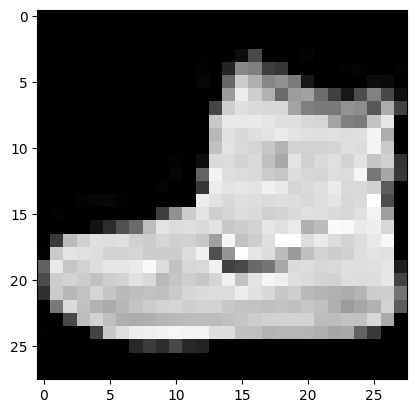

In [88]:
plt.imshow(image, 'gray')
plt.show()

In [89]:
type(train_x)

numpy.ndarray

In [90]:
# (28, 28) => (1, 28, 28, 1)  (batch, height, width, channel)
image = image[tf.newaxis, ..., tf.newaxis]
image.shape

(1, 28, 28, 1)

In [91]:
image

image.dtype

# ★ int 타입으로 모델에 집어 넣으면 '에러' 난다!

dtype('uint8')

In [92]:
image = tf.cast(image, dtype=tf.float32)
image.dtype

tf.float32

# Conv2D 레이어

In [93]:
conv_layer = tf.keras.layers.Conv2D(3, 3, 1, padding='SAME')
conv_layer

<Conv2D name=conv2d, built=False>

In [95]:
# image 를 레이어에 넣어주고 output 을 확인해볼수 있다
conv_output = conv_layer(image)  # 입력 (1, 28, 28, 1)
print(type(conv_output))
conv_output.shape  # (1, 28, 28, 3)

<class 'tensorflow.python.framework.ops.EagerTensor'>


TensorShape([1, 28, 28, 3])

In [98]:
conv_layer = tf.keras.layers.Conv2D(5, 3, 1, padding='SAME')
conv_output = conv_layer(image)

conv_output.shape  # (1, 28, 28, 5)


TensorShape([1, 28, 28, 5])

In [99]:
conv_layer = tf.keras.layers.Conv2D(5, 3, 1, padding='VALID')
conv_output = conv_layer(image)

conv_output.shape  # (1, 26, 26, 5)

TensorShape([1, 26, 26, 5])

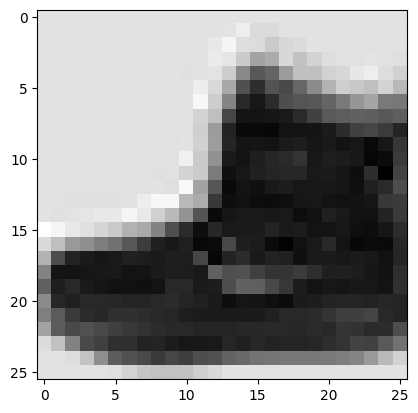

In [100]:
# 첫번째 채널 하나만 시각화 해보자
plt.imshow(conv_output[0, :, :, 0], 'gray')
plt.show()

# ※ 실행할때 마다 결과들이 달라보이는 이유,
# 애시당초 filter 의 weight 들은 random 하게 초기화되어 동작하기 때문

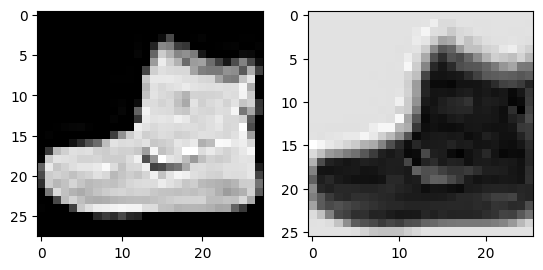

In [101]:
# 원본 이미지와 비교
plt.subplot(1, 2, 1)
plt.imshow(image[0, ..., 0], 'gray')

plt.subplot(1, 2, 2)
plt.imshow(conv_output[0, ..., 0], 'gray')

plt.show()

In [102]:
# 원본 이미지 값의 범위
np.min(image), np.max(image)

(np.float32(0.0), np.float32(255.0))

In [103]:
# Conv2D 를 거치면서 변한 값들
np.min(conv_output), np.max(conv_output)

(np.float32(-252.06628), np.float32(194.66533))

### layer 의 get_weights()

In [104]:
weights = conv_layer.get_weights()  # array 2개가 담긴 list 리턴!
print(weights[0].shape, weights[1].shape)

# [0] 번째 weight  => (3, 3, 1, 5)   (kernel_h, kernel_w, input_channel, filter개수)
# [1] 번째 bias    => (5,)           (filter개수, )

weights

(3, 3, 1, 5) (5,)


[array([[[[-0.2909348 , -0.14063875,  0.15655312, -0.23015079,
           -0.3141532 ]],
 
         [[-0.2766037 ,  0.19055656,  0.13376388,  0.24037156,
           -0.30959177]],
 
         [[-0.08204374,  0.22672656,  0.04234108, -0.08702636,
            0.11133274]]],
 
 
        [[[-0.27689672, -0.24607801,  0.2556167 ,  0.03354278,
            0.32127836]],
 
         [[ 0.10385942, -0.26386747,  0.30829588, -0.07460722,
           -0.2574634 ]],
 
         [[-0.24071145, -0.06998396, -0.13368353, -0.06869945,
           -0.13930432]]],
 
 
        [[[-0.10047174,  0.20989385, -0.06645855,  0.20087531,
            0.23255286]],
 
         [[-0.07729396,  0.03029075, -0.09096885,  0.28610602,
           -0.16372156]],
 
         [[ 0.20607719,  0.1678069 ,  0.17326918, -0.19100174,
           -0.26297173]]]], dtype=float32),
 array([0., 0., 0., 0., 0.], dtype=float32)]

In [105]:
# layer 의 param 개수
weights[0].size + weights[1].size


50

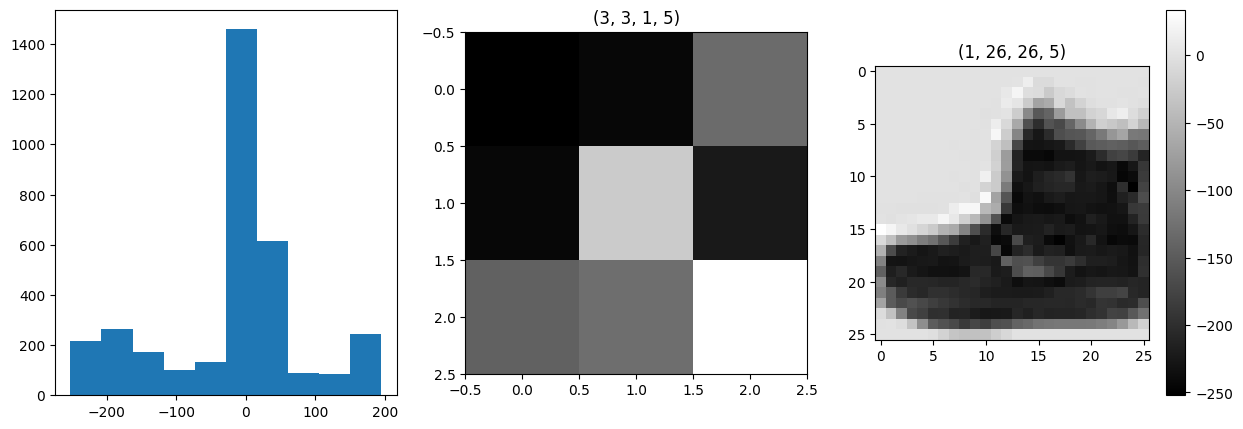

In [106]:
# 시각화
#  1. 이미지 히스토그램,   2. filter    3 output

plt.figure(figsize=(15, 5))

# 1 히스토그램
plt.subplot(131)
plt.hist(conv_output.numpy().ravel())

# 2 filter
plt.subplot(132)
plt.title(weights[0].shape)
plt.imshow(weights[0][:, :, 0, 0], 'gray')   # 맨 앞 filter 의 (3, 3) 값만 시각화

# 3 output
plt.subplot(133)
plt.title(conv_output.shape)  # (1, 26, 26, 5)
plt.imshow(conv_output[0, :, :, 0], 'gray')
plt.colorbar()

plt.show()


# ReLU 레이어
![](https://blog.kakaocdn.net/dn/vgJna/btqQzRGmwcO/TK3KTMlz4CYag8rBTKfYkK/img.png)

In [107]:
# ReLU 레이어 만들기
act_layer = tf.keras.layers.ReLU()
act_output = act_layer(conv_output)

print(act_output.shape) # (1, 26, 26, 5) shape 의 변화는 없다

act_output

(1, 26, 26, 5)


<tf.Tensor: shape=(1, 26, 26, 5), dtype=float32, numpy=
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
          0.00000000e+00, 0.00000000e+00],
         ...,
     

In [108]:
# 0 미만의 값들은 0으로 바뀌었다!
np.min(act_output), np.max(act_output)

(np.float32(0.0), np.float32(194.66533))

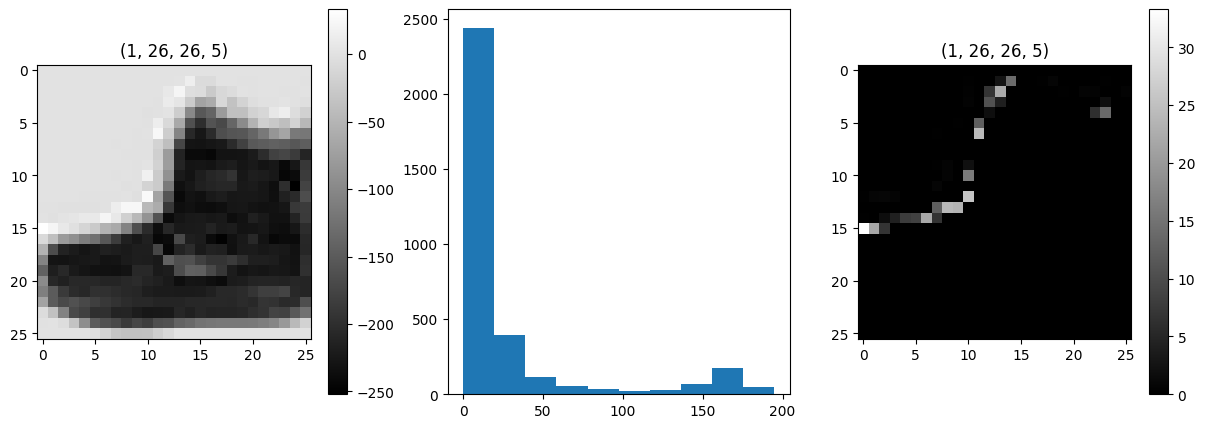

In [109]:
plt.figure(figsize=(15, 5))


# 1 이전 conv 출력
plt.subplot(131)
plt.title(conv_output.shape)  # (1, 26, 26, 5)
plt.imshow(conv_output[0, ..., 0], 'gray')
plt.colorbar()

# 2 act_output histogram
plt.subplot(132)
plt.hist(act_output.numpy().ravel())

# 3 act_output
plt.subplot(133)
plt.title(act_output.shape)  # (1, 26, 26, 5)
plt.imshow(act_output[0, ..., 0], 'gray')
plt.colorbar()


plt.show()


In [110]:
act_output.shape

TensorShape([1, 26, 26, 5])

# MaxPool2D 레이어

In [111]:
pool_layer = tf.keras.layers.MaxPool2D(2)

pool_output = pool_layer(act_output)
print(pool_output.shape) # (1, 13, 13, 5)

(1, 13, 13, 5)


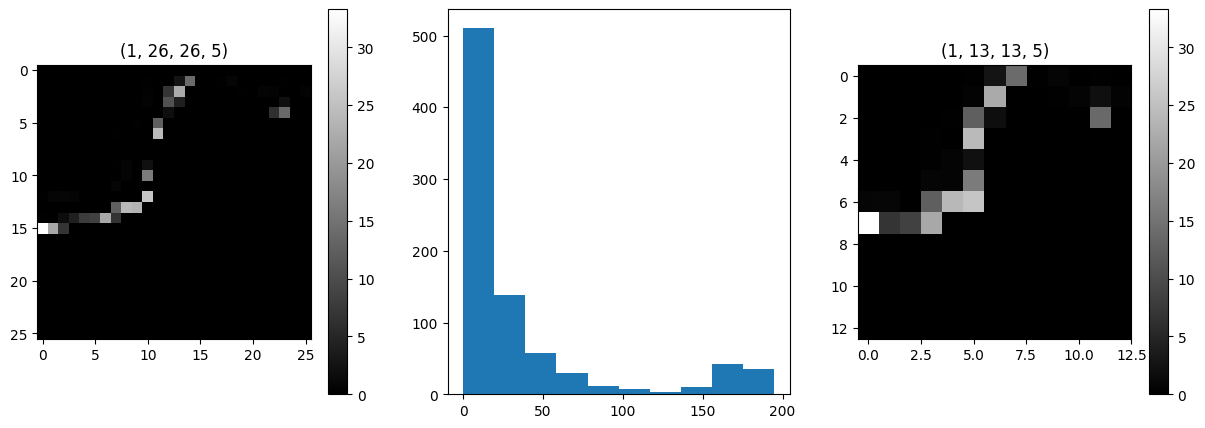

In [114]:
plt.figure(figsize=(15, 5))


# 1 이전 act_ouput
plt.subplot(131)
plt.title(act_output.shape)  # (1, 26, 26, 5)
plt.imshow(act_output[0, :, :, 0], 'gray')
plt.colorbar()

# 2 pool_output histogram
plt.subplot(132)
plt.hist(pool_output.numpy().ravel())

# 3 pool_output
plt.subplot(133)
plt.title(pool_output.shape)  # (1, 13, 13, 5)
plt.imshow(pool_output[0, :, :, 0], 'gray')
plt.colorbar()


plt.show()

In [115]:
pool_output.shape

TensorShape([1, 13, 13, 5])

# Flatten 레이어

In [ ]:
flat_layer = tf.keras.layers.🔹TODO

flat_output = 🔹TODO # (1, 845) <-  (1, 13, 13, 5)
print(flat_output.shape)  # (1, 845)

In [ ]:
plt.figure(figsize=(10, 5))

# 1 히스토그램
plt.subplot(211)
plt.hist(🔹TODO)

# 3
plt.subplot(212)
plt.title(🔹TODO)
plt.imshow(🔹TODO)

plt.show()

In [ ]:
#